In [7]:
library(data.table)
combined_DAP_JAN_028_ATAC=fread("~/github_reproducibility/table_S2.csv")
all_gene_ids=unique(combined_DAP_JAN_028_ATAC %>%
filter(p_weight < 0.05 / 230000)%>%
pull(gene_ID))

In [8]:
length(all_gene_ids)


[1] 50114

In [9]:
palantir_erythroid_peaks_from_NT=read.table('~/JAN_028/peak_communities_JAN_028_NT_cells_post_palantir.csv',header=TRUE,sep=',')
palantir_erythroid_peaks_from_NT=palantir_erythroid_peaks_from_NT %>%
filter(X0 %in% c(2,10,18,23,25))%>%
pull(X)

In [10]:
length(palantir_erythroid_peaks_from_NT)


[1] 29555

In [11]:
length(intersect(all_gene_ids, palantir_erythroid_peaks_from_NT))


[1] 8690

In [13]:
`%notin%` <- Negate(`%in%`)

length(which(all_gene_ids %notin% palantir_erythroid_peaks_from_NT))


[1] 41424

In [14]:
length(which(palantir_erythroid_peaks_from_NT %notin% all_gene_ids))


[1] 20865

Intersect between two annotations:

In [ ]:
folder1="/home/jupyter/github_reproducibility/ldsc_analysis_peaks_correlated_with_erythroid_differentiation"
folder2="/home/jupyter/github_reproducibility/ldsc_analysis_TF_sensitive_peaks"
folder3="/home/jupyter/github_reproducibility/ldsc_analysis_INTERSECT_peaks_correlated_with_erythroid_differentiation_and_TF_sensitive_peaks"
lastColumnName="INTERSECT_peaks_correlated_with_erythroid_differentiation_and_TF_sensitive_peaks"

mkdir -p "$folder3"
cd "$folder3"
rm *
for i in {1..22}
do
    echo $i
    file1="$folder1/custom_annot${i}.annot.gz"
    file2="$folder2/custom_annot${i}.annot.gz"
    outputFile="$folder3/custom_annot${i}.annot.gz"
    awk -v colName="$lastColumnName" 'BEGIN{OFS="\t"} NR==FNR{if(NR==1){print $1,$2,$3,$4,colName}else{a[$1,$2,$3]=$5}} NR!=FNR{if(FNR>1)print $1,$2,$3,$4,((a[$1,$2,$3]==1 && $5==1)?1:0)}' <(zcat "$file1") <(zcat "$file2") | gzip > "$outputFile"
done

echo "Processing complete."


Copy files to the bucket:

In [ ]:
cd /home/jupyter/github_reproducibility/ldsc_analysis_INTERSECT_peaks_correlated_with_erythroid_differentiation_and_TF_sensitive_peaks/
gsutil cp *annot.gz gs://bucket_path_1/


Run WDL WDL_LDSC in Terra.bio

Next, copy back the results from the WDL output into a folder

In [ ]:
mkdir /output/path/post_ldsc_files_1/
cd /output/path/post_ldsc_files_1/
gsutil cp gs://bucket_path_1_POST_LDSC/* .
for file in *.tar.gz; do
    tar -zxvf "$file"
done


And you need these files too that you uploaded to run the WDL

In [ ]:
cd local_files/
gsutil cp gs://bucket_path_1/* .



In [ ]:
mkdir /output/path/post_ldsc_files_1/
cd /output/path/post_ldsc_files_1/

conda activate ldsc
ldsc_path="/home/jmartinr/utilities/ldsc/ldsc.py"

sumstats_dir="/home/jmartinr/ldsc_vuckovic/output"

output_dir='/output/path/post_ldsc_files_1/'
ref_ld_chr_baseline="/home/jmartinr/ldsc_vuckovic/data/1000G_EUR_Phase3_baseline/baseline."
ref_ld_chr_responsive="/output/path/post_ldsc_files_1/custom_annot."
w_ld_chr="/home/jmartinr/ldsc_vuckovic/data/weights_hm3_no_hla/weights."
frqfile_chr="/home/jmartinr/ldsc_vuckovic/data/1000G_Phase3_frq/1000G.EUR.QC."

declare -a files=(
    "BCX2_RBC_EA_GWAMA"
  "BCX2_HGB_EA_GWAMA"
  "BCX2_HCT_EA_GWAMA"
  "BCX2_MCH_EA_GWAMA"
  "BCX2_MCV_EA_GWAMA"
  "BCX2_MCHC_EA_GWAMA"
  "BCX2_RDW_EA_GWAMA"
  "BCX2_WBC_EA_GWAMA"
  "BCX2_NEU_EA_GWAMA"
  "BCX2_LYM_EA_GWAMA"
  "BCX2_MON_EA_GWAMA"
  "BCX2_BAS_EA_GWAMA"
  "BCX2_EOS_EA_GWAMA"
  "BCX2_PLT_EA_GWAMA"
  "BCX2_MPV_EA_GWAMA"
)


for file_basename in "${files[@]}"; do
  sumstats_file="${sumstats_dir}/${file_basename}.sumstats.gz"
    
python $ldsc_path \
  --h2 $sumstats_file \
  --ref-ld-chr /output/path/post_ldsc_files_1/local_files/custom_annot,/home/jmartinr/ldsc_vuckovic/data/1000G_EUR_Phase3_baseline/baseline. \
  --w-ld-chr $w_ld_chr \
    --overlap-annot \
  --frqfile-chr $frqfile_chr \
  --out "${output_dir}/${file_basename}ldsc_analysis_INTERSECT_peaks_correlated_with_erythroid_differentiation_and_TF_sensitive_peaks_POST_LDSC" > "${output_dir}/${file_basename}ldsc_analysis_INTERSECT_peaks_correlated_with_erythroid_differentiation_and_TF_sensitive_peaks_POST_LDSC.log" 2>&1 &

done

wait

echo "All LDSC analyses have been run in parallel."

In [ ]:
#!/bin/bash

LOG_DIR="/output/path/post_ldsc_files_1"
OUTPUT_FILE="ldsc_analysis_name_of_analysis_extracted_data.csv"
cd "$LOG_DIR" || { echo "Directory not found: $LOG_DIR"; exit 1; }

echo "Trait,Prop._SNPs,Prop._h2,Prop._h2_std_error,Enrichment,Enrichment_Std_Error,Enrichment_p" > "$OUTPUT_FILE"

for file in "$LOG_DIR"/*_EA_GWAMAldsc_analysis_name_of_analysis.results; do
    trait=$(basename "$file" | sed -E 's/BCX2_(.*)_EA_GWAMAldsc_analysis_name_of_analysis.results/\1/')

    readarray -t row_data < <(tail -n +2 "$file" | head -1)
    
    prop_snps=$(echo "${row_data[0]}" | awk '{print $2}')
    prop_h2=$(echo "${row_data[0]}" | awk '{print $3}')
    prop_h2_std_error=$(echo "${row_data[0]}" | awk '{print $4}')
    enrichment=$(echo "${row_data[0]}" | awk '{print $5}')
    enrichment_std_error=$(echo "${row_data[0]}" | awk '{print $6}')
    enrichment_p=$(echo "${row_data[0]}" | awk '{print $7}')


    echo "$trait,$prop_snps,$prop_h2,$prop_h2_std_error,$enrichment,$enrichment_std_error,$enrichment_p" >> "$OUTPUT_FILE"
done

echo "Data extraction complete. Output saved to $OUTPUT_FILE."

gsutil -m cp "$OUTPUT_FILE" gs://bucket_path/ldsc/


In [ ]:
gsutil -m cp *extracted_data.csv gs://bucket_path/ldsc/

Do the same thing for any other annotation.

## Plotting everything together in the same plot:

In [ ]:
gsutil -m cp gs://bucket_path/ldsc/*extracted_data.csv ~/destination_folder/

In [58]:
output_folder='~/0_perturb_multiome_manuscript_figures/'

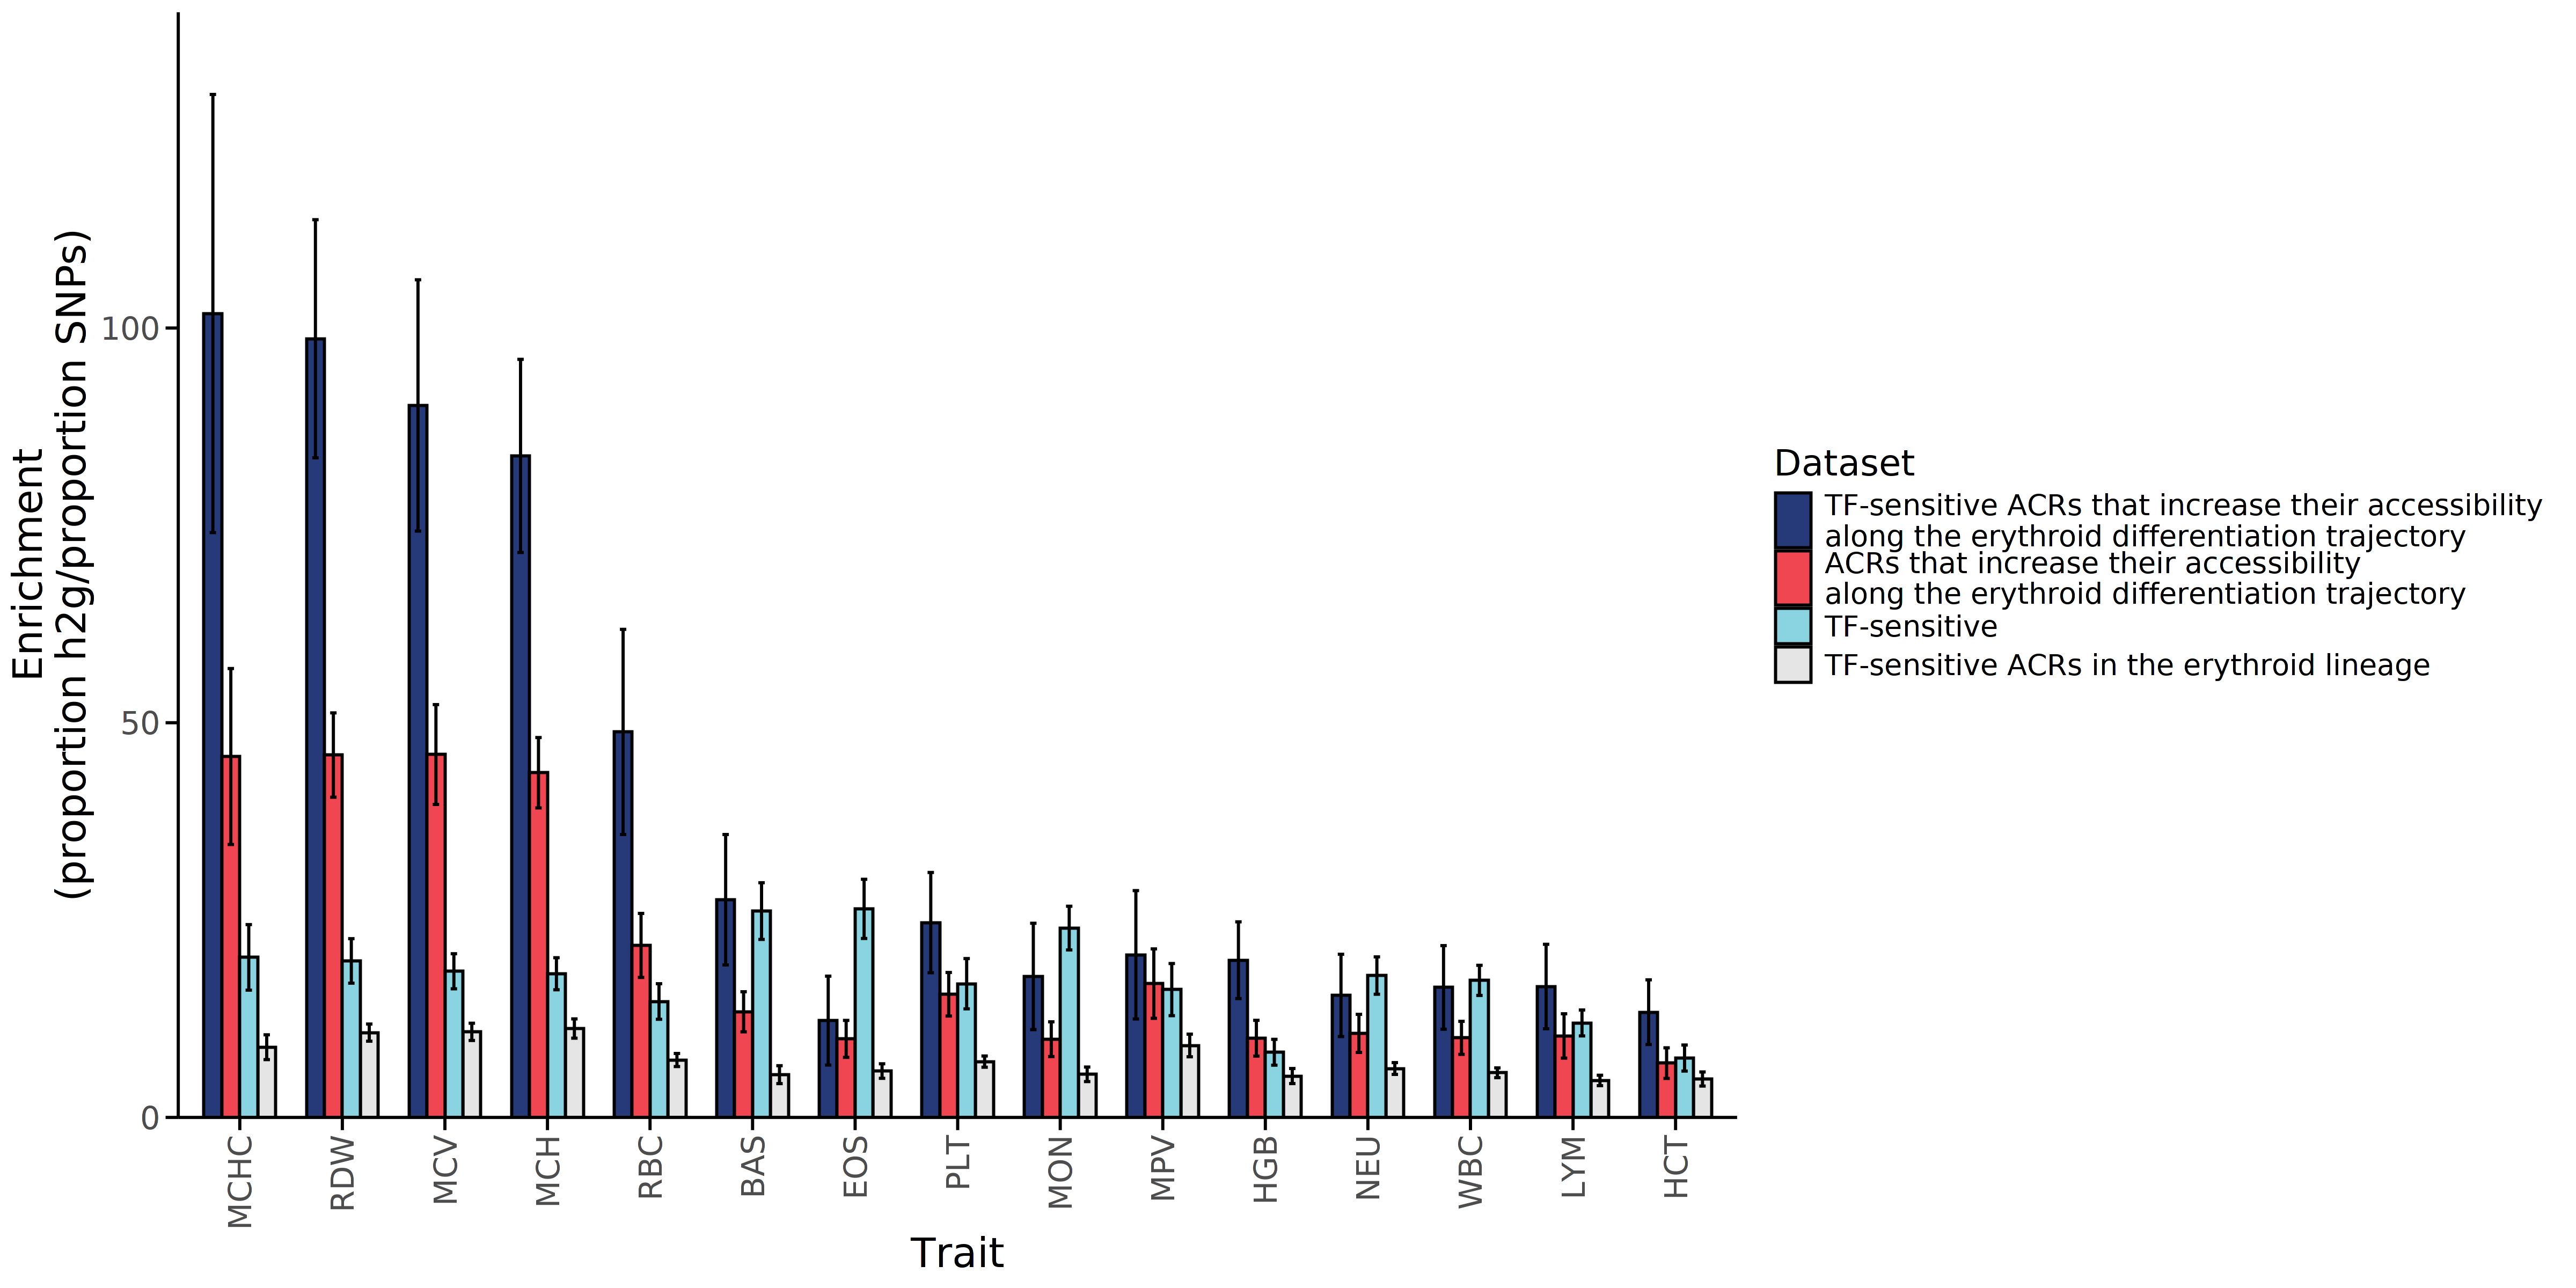

In [59]:
width = 16
height = 8
figure_name = 'all_enrichments_grouped.pdf'
output_folder = "~/destination_folder/"  
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 300)

library(ggplot2)
library(dplyr)
library(BuenColors)

data1 = read.table("~/destination_folder/erythroid_tf_sensitive_extracted_data.csv", sep = ',', header = TRUE)
data2 = read.table("~/destination_folder/non_tf_sensitive_extracted_data.csv", sep = ',', header = TRUE)
data3 = read.table("~/destination_folder/erythroid_extracted_data.csv", sep = ',', header = TRUE)
data4 = read.table("~/destination_folder/tf_sensitive_extracted_data.csv", sep = ',', header = TRUE)

data1$Dataset = "Dataset1"
data2$Dataset = "Dataset2"
data3$Dataset = "Dataset3"
data4$Dataset = "Dataset4"

data = bind_rows(data1, data2, 
                 data3, data4)

colnames(data)[1] = 'Trait'
colnames(data)[5] = 'Enrichment_2'
colnames(data)[6] = 'Enrichment_se'

data$Lineage <- ifelse(grepl('LYM', data$Trait), 'Lymphoid',
                  ifelse(grepl('RBC|HGB|HCT|MCH|MCV|MCHC|RDW', data$Trait), 'Erythroid',
                  ifelse(grepl('WBC|NEU|MON|BAS|EOS', data$Trait), 'Myeloid',
                  ifelse(grepl('PLT|MPV', data$Trait), 'Platelets', 'Unknown'))))

responsive_order <- data %>%
  arrange(desc(Enrichment_2)) %>%
  .$Trait

data$Trait <- factor(data$Trait, levels = unique(responsive_order))
data$Dataset <- factor(data$Dataset, levels = c("Dataset1",
                                               "Dataset3",
                                               "Dataset4","Dataset2"))


dataset_colors <- c('Dataset1' = "#263A79",
                    'Dataset2' = "grey90",
                    'Dataset3' = "#EF4651",
                    'Dataset4' = "#8AD4E2")

p <- ggplot(data, aes(x = Trait, y = Enrichment_2, fill = Dataset)) +
  geom_bar(color = 'black', stat = "identity", position = position_dodge(), width = 0.7) +
  geom_errorbar(aes(ymin = Enrichment_2 - Enrichment_se, ymax = Enrichment_2 + Enrichment_se), 
                position = position_dodge(width = 0.7), 
                width = 0.25) +
  scale_fill_manual(values = dataset_colors,
  labels = c('Dataset1' = 'TF-sensitive ACRs that increase their accessibility\nalong the erythroid differentiation trajectory',
             'Dataset2' = 'TF-sensitive ACRs in the erythroid lineage',
             'Dataset3' = 'ACRs that increase their accessibility\nalong the erythroid differentiation trajectory',
             'Dataset4' = 'TF-sensitive')) +
  labs(
       x = 'Trait', 
       y = 'Enrichment\n(proportion h2g/proportion SNPs)') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title = element_text(size = 18),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 14),
    axis.text.y = element_text(size = 14),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.ticks = element_line(color = "black", size = 0.5), 
    axis.ticks.length = unit(2, "mm"),
    axis.line = element_line(color = "black"),
    strip.text = element_text(size = 16),
    strip.background = element_blank()
  ) + 
  scale_y_continuous(expand = c(0, 0), limits = c(0, 140))

print(p)

# Save the plot
#ggsave(paste(output_folder, figure_name, sep = ""), plot = p, dpi = 600, width = width, height = height)

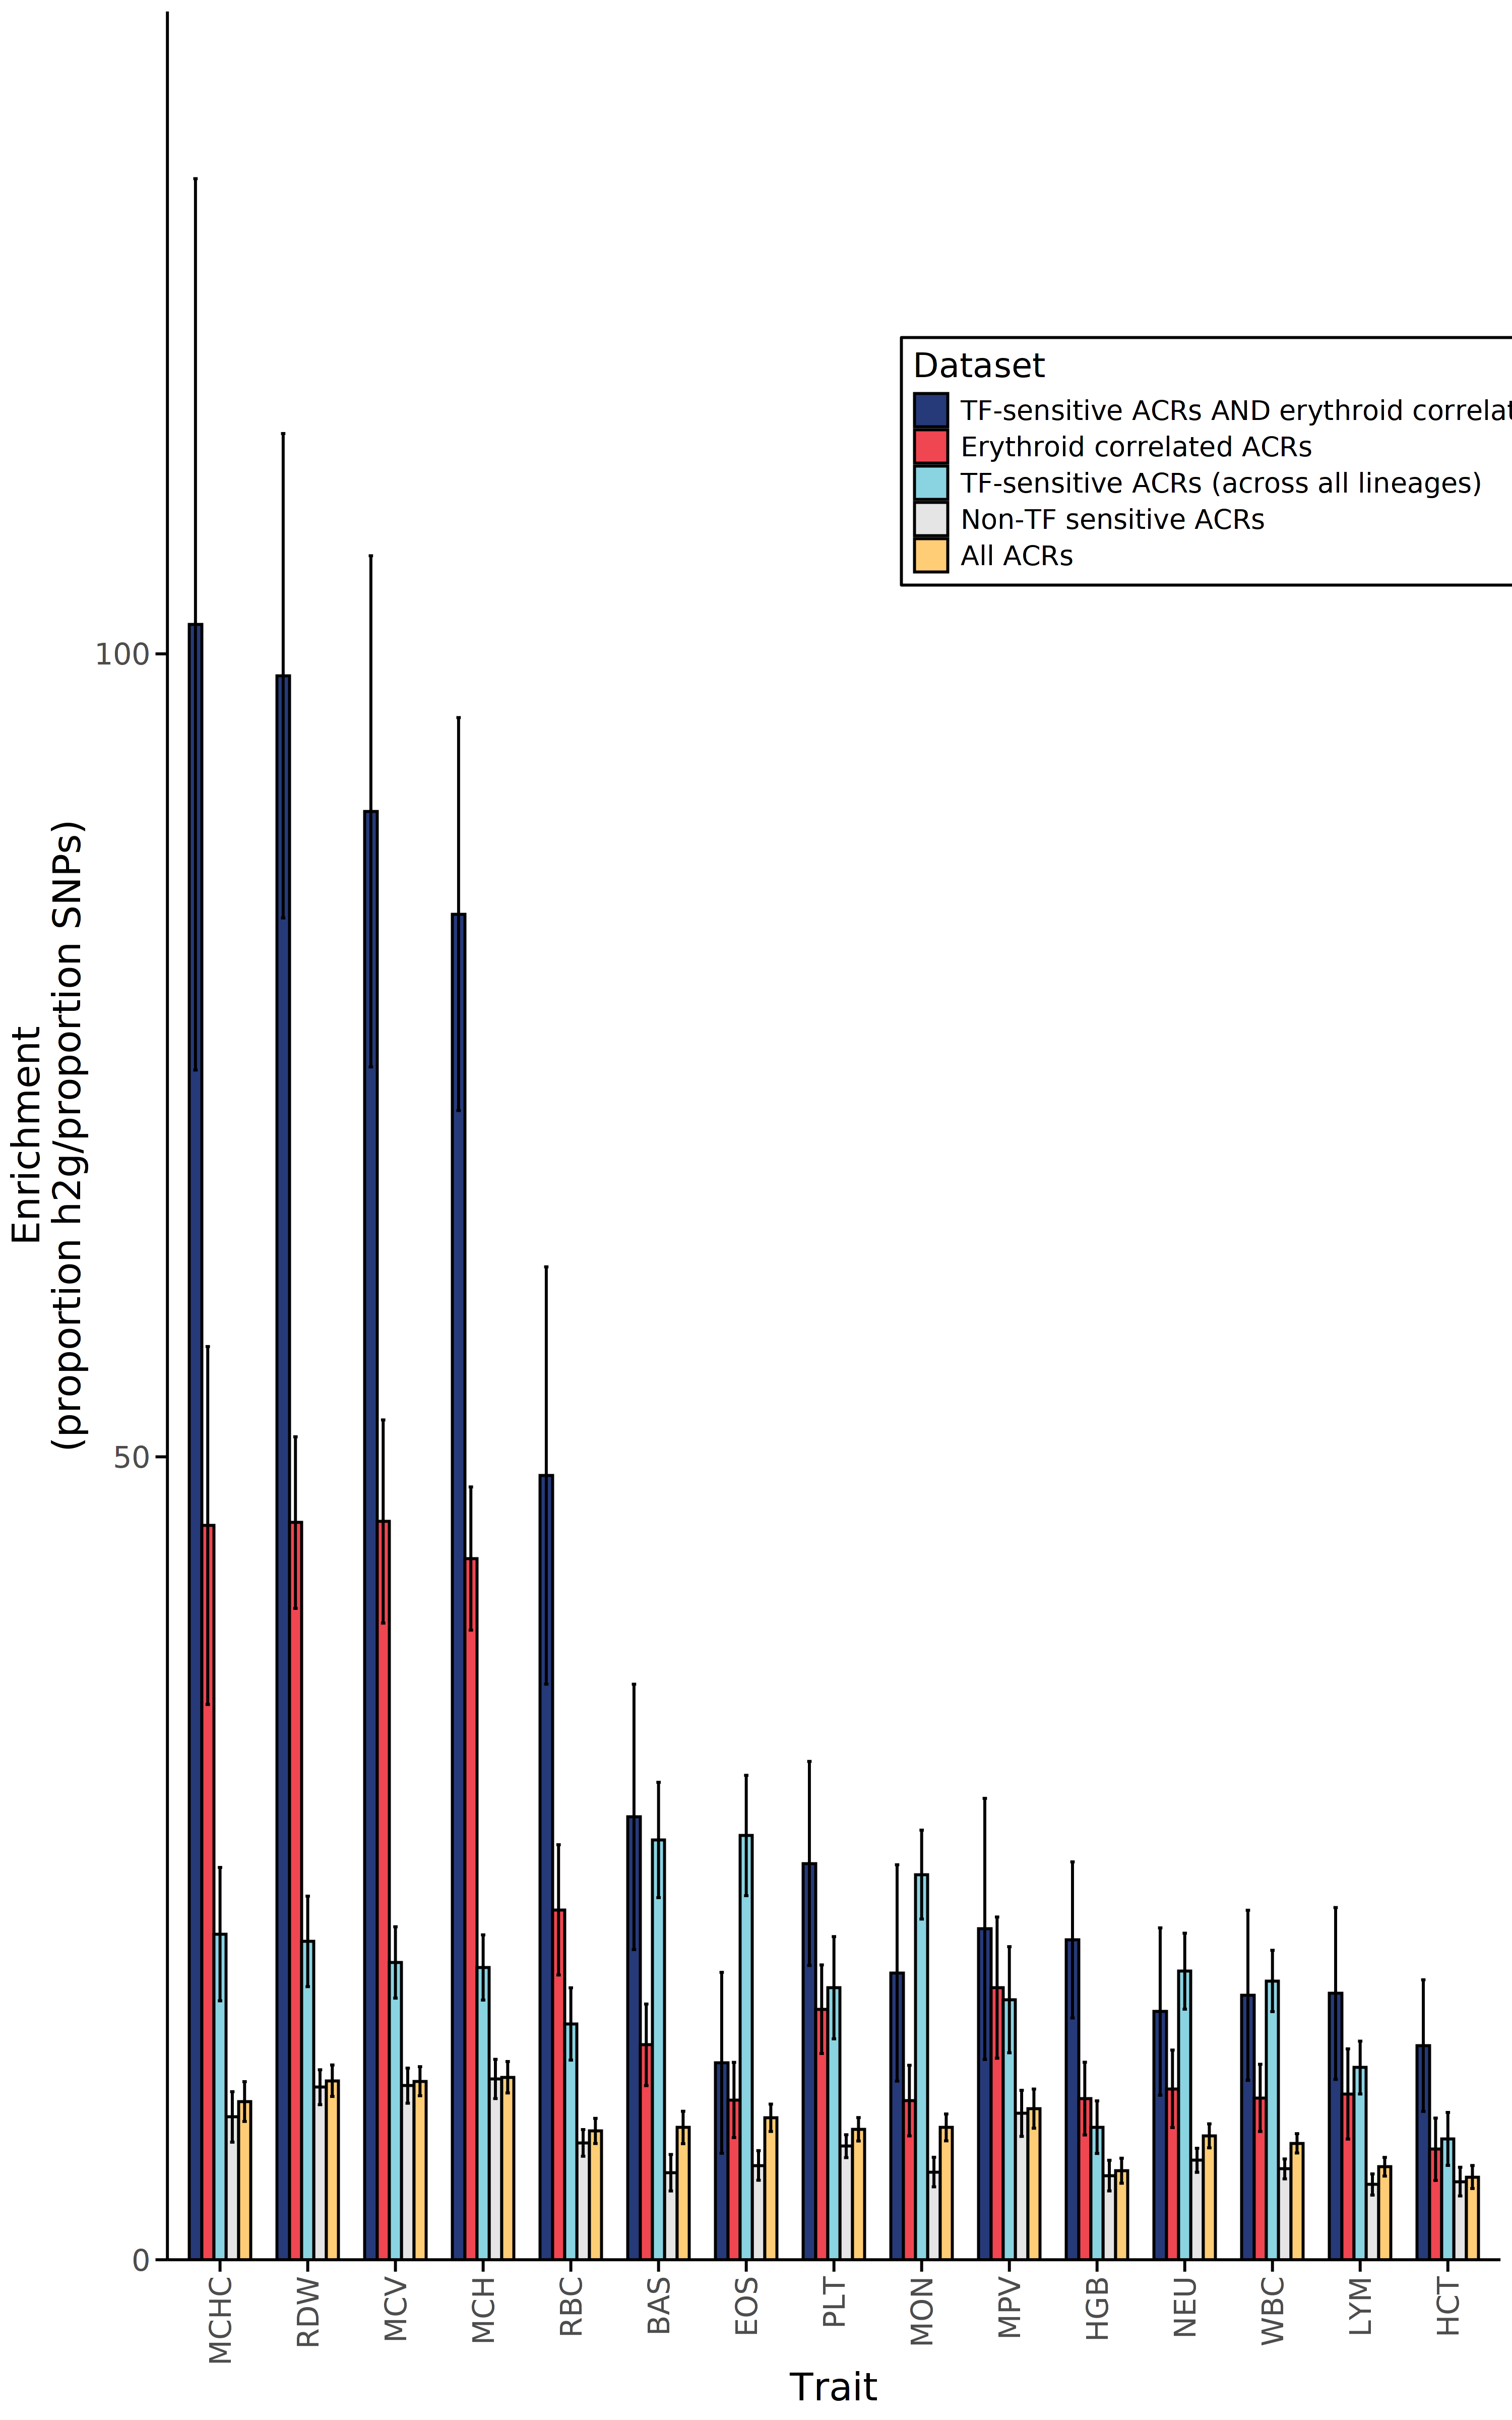

In [60]:
width = 10
height = 16
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = 300)
figure_name = 'all_erythroid_enrichments_grouped.pdf'
output_folder = "~/0_perturb_multiome_manuscript_figures/"  

data5 = read.table("~/destination_folder/all_peaks_extracted_data.csv", sep = ',', header = TRUE)

data5$Dataset = "Dataset5"

data = bind_rows(data1, data2, data3, data4, data5)

colnames(data)[1] = 'Trait'
colnames(data)[5] = 'Enrichment_2'
colnames(data)[6] = 'Enrichment_se'

data$Lineage <- ifelse(grepl('LYM', data$Trait), 'Lymphoid',
                  ifelse(grepl('RBC|HGB|HCT|MCH|MCV|MCHC|RDW', data$Trait), 'Erythroid',
                  ifelse(grepl('WBC|NEU|MON|BAS|EOS', data$Trait), 'Myeloid',
                  ifelse(grepl('PLT|MPV', data$Trait), 'Platelets', 'Unknown'))))

responsive_order <- data %>%
  arrange(desc(Enrichment_2)) %>%
  .$Trait

data$Trait <- factor(data$Trait, levels = unique(responsive_order))
data$Dataset <- factor(data$Dataset, levels = c("Dataset1", "Dataset3", "Dataset4", "Dataset2", "Dataset5"))

dataset_colors <- c(
  'Dataset1' = "#263A79",
  'Dataset2' = "grey90",
  'Dataset3' = "#EF4651",
  'Dataset4' = "#8AD4E2",
  'Dataset5' = "#FFCD76"
)

dataset_labels <- c(
  'Dataset1' = 'TF-sensitive ACRs AND erythroid correlated',
  'Dataset2' = 'Non-TF sensitive ACRs',
  'Dataset3' = 'Erythroid correlated ACRs',
  'Dataset4' = 'TF-sensitive ACRs (across all lineages)',
  'Dataset5' = 'All ACRs'
)

p <- ggplot(data, aes(x = Trait, y = Enrichment_2, fill = Dataset)) +
  geom_bar(color = 'black', stat = "identity", position = position_dodge(), width = 0.7) +
  geom_errorbar(aes(ymin = Enrichment_2 - Enrichment_se, ymax = Enrichment_2 + Enrichment_se), 
                position = position_dodge(width = 0.7), 
                width = 0.25) +
  scale_fill_manual(values = dataset_colors, labels = dataset_labels) +
  labs(
       x = 'Trait', 
       y = 'Enrichment\n(proportion h2g/proportion SNPs)') +
  theme_minimal() +
  theme(
    text = element_text(size = 16),
    axis.title = element_text(size = 18),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 14),
    axis.text.y = element_text(size = 14),
    panel.background = element_blank(),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.ticks = element_line(color = "black", size = 0.5), 
    axis.ticks.length = unit(2, "mm"),
    axis.line = element_line(color = "black"),
    strip.text = element_text(size = 16),
    strip.background = element_blank(),
    legend.position = c(0.8, 0.8), # Set the legend position
    legend.background = element_rect(fill = "white", color = "black") # Optional: background for better readability
  ) + 
  scale_y_continuous(expand = c(0, 0), limits = c(0, 140))

print(p)


ggsave(paste(output_folder, figure_name, sep = ""), plot = p, dpi = 600, width = width, height = height)
